# When one campaign-overlap model fails: an intuitive person-level market

This notebook asks one narrow question: **can a single cross-publisher overlap learned from canonical large Reach campaigns transfer to campaigns that select different people?**

It models people and publisher-local delivery—not account identifiers, RID-to-person mapping, Dirac mixtures, or a production VID system. Each row is one known synthetic person who can be reachable on either or both publishers. The two publishers never exchange delivery information and never take budget or impressions from one another.

The model deliberately uses fixed reach so the tests can hold campaign size constant and isolate audience composition. Opportunity and cost determine **which people fill each publisher's reach**, not how much reach the publisher receives. A separate budget-based implementation would answer a different question.

No overlap rate is assigned to a campaign. Overlap is measured only after each publisher independently selects its audience.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

if "google.colab" in sys.modules:
    repo = Path("/content/calibrated-vid")
    if not repo.exists():
        subprocess.run([
            "git", "clone", "--depth", "1", "--branch", "main",
            "https://github.com/world-federation-of-advertisers/calibrated-vid.git",
            str(repo),
        ], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(repo)], check=True)
    os.chdir(repo)

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

## The intuitive mechanism

The eligible market contains people with different publisher activity, placement use, time-of-day availability, response propensity, and opportunity cost.

For a person $i$ on publisher $p$, a Reach campaign ranks roughly by:

$$w_{ip}=\frac{\text{opportunity}_{ip}}{\text{cost}_{ip}}$$

A Traffic campaign also values publisher-local response:

$$w^{Traffic}_{ip}=\frac{\text{opportunity}_{ip}\times\text{response}_{ip}^{\alpha}}{\text{cost}_{ip}}$$

The ranking is not a literal auction or click probability. It is a compact representation of who is available and economical under a campaign's objective and settings. A random component prevents delivery from being perfectly deterministic.

Three observable mechanisms are isolated:

1. **Response contrast:** publishers may value different people under Traffic optimization.
2. **Activity depth:** a medium campaign takes the most available portion of a publisher's audience; a large campaign extends farther down that same ordering.
3. **Campaign profiles:** placement, flight length, and time window alter which people are locally available.

The sensitivity notebook turns each mechanism down to zero and increases it gradually.

### In plain language

Each publisher has its own ordering of people. Some people appear often and are inexpensive to reach; others appear less often or cost more. A Reach campaign generally fills its audience from the easiest opportunities first. A Traffic campaign changes that order by giving extra value to likely responders.

The publishers do not coordinate and one publisher does not take impressions from the other. We compare the two independently selected audiences only after delivery is complete.

In [2]:
import html
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from IPython.display import HTML, display

from calibrated_vid.intuitive_market import PROFILE_BY_NAME, PROFILES, SEGMENTS, run_experiment

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
OUTPUT = ROOT / "outputs" / "behavioral_market"
campaigns, report = run_experiment(OUTPUT)
diagnostic = report["diagnostics"]

def show_table(rows, columns, digits=2):
    head = "".join(f"<th>{html.escape(label)}</th>" for _, label in columns)
    body = []
    for row in rows:
        cells = []
        for key, _ in columns:
            value = row[key]
            if isinstance(value, float):
                value = f"{value:.{digits}f}"
            cells.append(f"<td>{html.escape(str(value))}</td>")
        body.append("<tr>" + "".join(cells) + "</tr>")
    display(HTML("<table><thead><tr>" + head + "</tr></thead><tbody>" + "".join(body) + "</tbody></table>"))

diagnostic

{'baseline_overlap_percent': 32.72951388888889,
 'objective': {'pairs': 32,
  'traffic_lower_share': 1.0,
  'traffic_minus_reach_median_points': -13.218055555555559,
  'p10_points': -16.636388888888888,
  'p90_points': -0.8797222222222255},
 'direction': {'pairs': 24,
  'medium_large_higher_share': 1.0,
  'medium_large_minus_large_medium_median_points': 14.666666666666664,
  'p10_points': 14.342592592592595,
  'p90_points': 15.187037037037035},
 'large_profiles': {'campaigns': 70,
  'p10_overlap_percent': 17.589722222222225,
  'median_overlap_percent': 28.061111111111114,
  'p90_overlap_percent': 40.170833333333334,
  'p10_p90_width_points': 22.58111111111111,
  'profiles': [{'profile': 'broad_long',
    'label': 'Long flight, broad placements',
    'campaigns': 10,
    'median_overlap_percent': 32.795833333333334,
    'p10_overlap_percent': 32.62,
    'p90_overlap_percent': 32.94444444444444},
   {'profile': 'feed_short',
    'label': 'Short flight, feed-heavy',
    'campaigns': 10,
 

## People and campaign profiles

The archetypes are explanatory summaries, not advertiser targeting labels. Importantly, they are stable across every campaign. Campaigns cannot choose an archetype directly.

- **Dual regulars** are frequently available on both publishers.
- **Publisher-heavy regulars** are much more available on one publisher.
- **Publisher-specific responders** are valued differently by Traffic delivery.
- **Feed, video, daytime, evening, and occasional users** become more or less available under named campaign profiles.

The newer model has no independent campaign-by-archetype opportunity shocks. Variation comes from campaign settings that can be named and inspected.

In [3]:
segment_rows = [{
    "segment": row.name,
    "population %": 100 * row.share,
    "activity A": 0.5 * (row.feed_a + row.video_a),
    "activity B": 0.5 * (row.feed_b + row.video_b),
    "click A": row.click_a,
    "click B": row.click_b,
} for row in SEGMENTS]
show_table(segment_rows, [
    ("segment", "Synthetic person type"),
    ("population %", "Population %"),
    ("activity A", "Activity A"),
    ("activity B", "Activity B"),
    ("click A", "Response A"),
    ("click B", "Response B"),
])

profile_rows = [{
    "profile": row.label,
    "days": row.active_days,
    "video A": 100 * row.video_share_a,
    "video B": 100 * row.video_share_b,
    "schedule": row.schedule,
} for row in PROFILES]
show_table(profile_rows, [
    ("profile", "Campaign profile"),
    ("days", "Active days"),
    ("video A", "Video share A %"),
    ("video B", "Video share B %"),
    ("schedule", "Time window"),
])

Synthetic person type,Population %,Activity A,Activity B,Response A,Response B
dual_daily,24.00,0.79,0.73,0.03,0.03
a_regular_dual_occasional,17.00,0.86,0.39,0.02,0.01
b_heavy_regular,23.00,0.12,0.92,0.01,0.02
dual_video_regular,10.00,0.67,0.65,0.04,0.04
a_response_regular,9.00,0.74,0.31,0.36,0.01
b_response_regular,9.00,0.28,0.78,0.01,0.36
daytime_dual,4.00,0.47,0.46,0.04,0.04
evening_video_dual,2.00,0.52,0.51,0.06,0.06
occasional_dual,2.00,0.20,0.19,0.02,0.02


Campaign profile,Active days,Video share A %,Video share B %,Time window
"Long flight, broad placements",42,35.00,35.00,broad
"Short flight, feed-heavy",10,5.00,5.00,broad
"Short flight, video-heavy",10,90.00,90.00,broad
"A feed-heavy, B video-heavy",18,8.00,88.00,broad
"A video-heavy, B feed-heavy",18,88.00,8.00,broad
"Both publishers: daytime-skewed, feed-heavy",18,10.00,10.00,daytime
"Both publishers: evening-skewed, video-heavy",18,82.00,82.00,evening


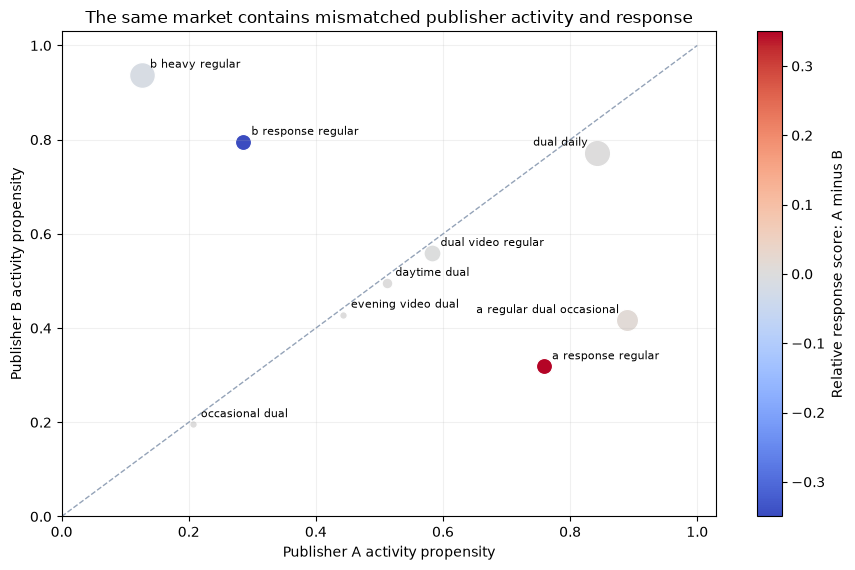

In [4]:
fig, ax = plt.subplots(figsize=(9.0, 5.8))
normalizer = plt.Normalize(-0.35, 0.35)
mapper = plt.cm.ScalarMappable(norm=normalizer, cmap="coolwarm")
for segment in SEGMENTS:
    activity_a = 0.65 * segment.feed_a + 0.35 * segment.video_a
    activity_b = 0.65 * segment.feed_b + 0.35 * segment.video_b
    response_asymmetry = segment.click_a - segment.click_b
    ax.scatter(
        activity_a,
        activity_b,
        s=1500 * segment.share,
        color=mapper.to_rgba(response_asymmetry),
        edgecolor="white",
        linewidth=0.9,
    )
    label_on_left = activity_a > 0.82
    ax.annotate(
        segment.name.replace("_", " "),
        (activity_a, activity_b),
        xytext=((-6 if label_on_left else 6), 5),
        textcoords="offset points",
        fontsize=8,
        ha=("right" if label_on_left else "left"),
    )
ax.plot([0, 1], [0, 1], color="#94a3b8", linewidth=1, linestyle="--")
ax.set(
    xlabel="Publisher A activity propensity",
    ylabel="Publisher B activity propensity",
    title="The same market contains mismatched publisher activity and response",
    xlim=(0, 1.03),
    ylim=(0, 1.03),
)
ax.grid(alpha=0.18)
fig.colorbar(mapper, ax=ax, label="Relative response score: A minus B")
fig.tight_layout()
fig.savefig(OUTPUT / "population_composition.png", dpi=180)
plt.show()

## Test 1: Traffic and Reach select different people

Every point is a matched pair. Reach and Traffic use the same population, reach totals, placements, flight, time window, costs, and random delivery draw. Only the objective changes.

Traffic values publisher-specific responders. When the strongest responders differ across publishers, the two Traffic audiences intersect less than the matched Reach audiences.

### What is happening and why

Reach is content to serve an inexpensive available person even if that person rarely clicks. Traffic is willing to prioritize a more expensive person when that person is much more likely to respond. If Publisher A's likely responders are different people from Publisher B's likely responders, the two Traffic audiences separate and their overlap falls.

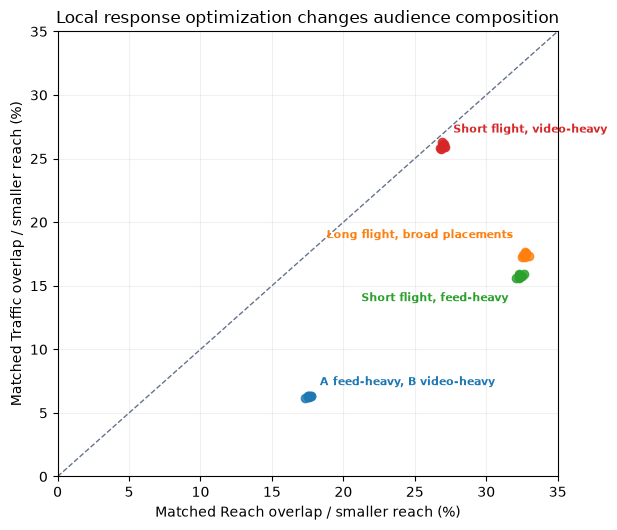

Matched pairs,Traffic-lower share,Median Traffic − Reach points,P10 difference,P90 difference
32,1.00,-13.22,-16.64,-0.88


In [5]:
evaluation = [row for row in campaigns if row.split == "evaluation"]
by_pair = {}
for row in evaluation:
    by_pair.setdefault(row.comparison_id, {})[row.scenario] = row
objective_pairs = [
    (rows["objective_reach"], rows["objective_traffic"])
    for rows in by_pair.values()
    if {"objective_reach", "objective_traffic"}.issubset(rows)
]
reach = 100 * np.asarray([left.overlap_rate for left, _ in objective_pairs])
traffic = 100 * np.asarray([right.overlap_rate for _, right in objective_pairs])
fig, ax = plt.subplots(figsize=(6.3, 5.4))
objective_profiles = sorted({left.profile for left, _ in objective_pairs})
profile_colors = {
    profile: plt.cm.tab10(index)
    for index, profile in enumerate(objective_profiles)
}
label_offsets = {
    "a_feed_b_video": ((8, 8), "left"),
    "broad_long": ((-8, 12), "right"),
    "feed_short": ((-8, -18), "right"),
    "video_short": ((8, 10), "left"),
}
for profile in objective_profiles:
    profile_pairs = [
        (left, right)
        for left, right in objective_pairs
        if left.profile == profile
    ]
    profile_reach = 100 * np.asarray([left.overlap_rate for left, _ in profile_pairs])
    profile_traffic = 100 * np.asarray([right.overlap_rate for _, right in profile_pairs])
    ax.scatter(
        profile_reach,
        profile_traffic,
        color=profile_colors[profile],
        alpha=0.82,
    )
    offset, alignment = label_offsets[profile]
    ax.annotate(
        PROFILE_BY_NAME[profile].label,
        (np.median(profile_reach), np.median(profile_traffic)),
        xytext=offset,
        textcoords="offset points",
        ha=alignment,
        fontsize=8,
        color=profile_colors[profile],
        weight="bold",
    )
limit = max(reach.max(), traffic.max()) + 2
ax.plot([0, limit], [0, limit], "--", color="#64748b", linewidth=1)
ax.set(xlabel="Matched Reach overlap / smaller reach (%)", ylabel="Matched Traffic overlap / smaller reach (%)", title="Local response optimization changes audience composition", xlim=(0, limit), ylim=(0, limit))
ax.grid(alpha=0.18)
fig.tight_layout()
fig.savefig(OUTPUT / "objective_pairing.png", dpi=180)
plt.show()
show_table([diagnostic["objective"]], [
    ("pairs", "Matched pairs"),
    ("traffic_lower_share", "Traffic-lower share"),
    ("traffic_minus_reach_median_points", "Median Traffic − Reach points"),
    ("p10_points", "P10 difference"),
    ("p90_points", "P90 difference"),
])

> **Test 1 conclusion.** A large-Reach average does not transfer when objective-specific delivery values different people on the two publishers. The effect disappears or reverses when publisher response rankings are made similar; the sensitivity notebook shows that boundary explicitly.

## Test 2: controlled direction test—size changes how deeply each publisher reaches

All 24 paired comparisons use the same Reach objective, target, long broad-placement profile, cost structure, and random draw. The medium and large reaches are simply reversed. Because the delivery profile is fixed, the two resulting clusters are expected to be tight: the test isolates the effect of size direction rather than representing every kind of Reach campaign.

The medium audience is nested inside the large audience for each publisher. Publisher A's most available users contain more dual-publisher regulars, while Publisher B's most available users contain more B-heavy regulars. A large campaign expands farther into each publisher's activity ordering. The resulting intersection therefore depends on which publisher supplies the medium audience.

### What is happening and why

A medium campaign stops after reaching a relatively small group of easy-to-reach people. A large campaign keeps going into less-active or more-expensive people. If the easiest people on Publisher A use both publishers while the easiest people on Publisher B are more B-specific, swapping which publisher is medium changes the shared audience—even though the same two reach totals are used.

The tightness of the clusters is a feature of this controlled comparison, not a claim that all medium-to-large campaigns behave alike. Test 3 changes campaign profiles and shows the much wider variation that appears across those conditions.

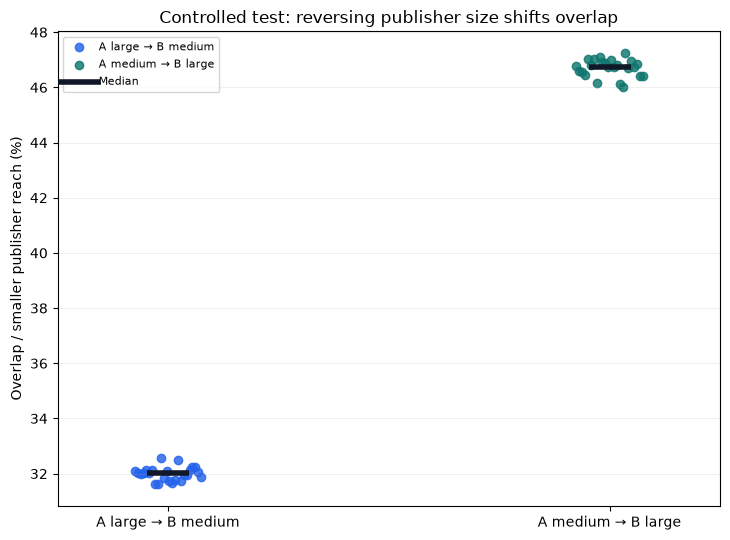

Matched pairs,Medium→large higher share,Median direction gap points,P10 gap,P90 gap
24,1.00,14.67,14.34,15.19


In [6]:
direction_pairs = [
    (rows["direction_medium_large"], rows["direction_large_medium"])
    for rows in by_pair.values()
    if {"direction_medium_large", "direction_large_medium"}.issubset(rows)
]
medium_large = 100 * np.asarray([left.overlap_rate for left, _ in direction_pairs])
large_medium = 100 * np.asarray([right.overlap_rate for _, right in direction_pairs])
fig, ax = plt.subplots(figsize=(7.4, 5.5))
jitter = np.linspace(-0.075, 0.075, len(direction_pairs))
ax.scatter(jitter, large_medium, color="#2563eb", alpha=0.82, label="A large → B medium")
ax.scatter(1.0 + jitter, medium_large, color="#0f766e", alpha=0.82, label="A medium → B large")
ax.scatter(
    [0.0, 1.0],
    [np.median(large_medium), np.median(medium_large)],
    marker="_",
    s=900,
    linewidth=4,
    color="#111827",
    label="Median",
    zorder=5,
)
ax.set(
    ylabel="Overlap / smaller publisher reach (%)",
    title="Controlled test: reversing publisher size shifts overlap",
    xticks=[0.0, 1.0],
    xticklabels=["A large → B medium", "A medium → B large"],
    xlim=(-0.25, 1.25),
)
ax.grid(axis="y", alpha=0.18)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT / "direction_pairing.png", dpi=180)
plt.show()
show_table([diagnostic["direction"]], [
    ("pairs", "Matched pairs"),
    ("medium_large_higher_share", "Medium→large higher share"),
    ("medium_large_minus_large_medium_median_points", "Median direction gap points"),
    ("p10_points", "P10 gap"),
    ("p90_points", "P90 gap"),
])

> **Test 2 conclusion.** Within one fixed delivery profile, reversing which publisher is large creates a consistent directional shift. The tight clusters show that controlled effect; they do not contradict Test 3's broad across-profile range. A large-to-large average cannot automatically represent both asymmetric directions, but real-world directional distributions can widen when campaign conditions also vary.

## Test 3: equal-size large Reach campaigns can encounter different active populations

Every campaign below has identical large Reach totals on both publishers and uses the Reach objective. Only named campaign conditions change.

Within a profile, repeated campaigns have very similar overlap. Most dispersion occurs **between explainable profiles**—for example, broad long-running delivery versus opposite placement mixes—not because the simulator draws arbitrary archetype shocks for every campaign. This is why Test 2's fixed-profile directional clusters are tight while the full large-Reach P10–P90 range is wide.

### What is happening and why

Two campaigns can each reach 36,000 people without reaching the same 36,000 people. A short feed-heavy campaign mostly sees frequent feed users. A video-heavy or daytime campaign sees a different available population. The total reach is held constant so the chart isolates this change in composition.

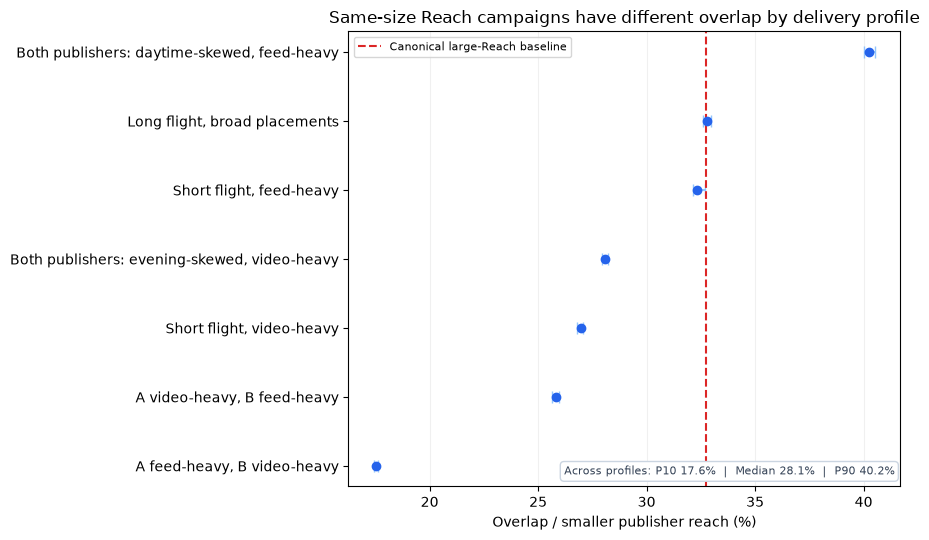

Campaigns,P10 overlap %,Median overlap %,P90 overlap %,P10–P90 width points
70,17.59,28.06,40.17,22.58


In [7]:
profiles = sorted(diagnostic["large_profiles"]["profiles"], key=lambda row: row["median_overlap_percent"])
fig, ax = plt.subplots(figsize=(9.2, 5.5))
y = np.arange(len(profiles))
med = np.asarray([row["median_overlap_percent"] for row in profiles])
low = med - np.asarray([row["p10_overlap_percent"] for row in profiles])
high = np.asarray([row["p90_overlap_percent"] for row in profiles]) - med
ax.errorbar(med, y, xerr=[low, high], fmt="o", color="#2563eb", ecolor="#93c5fd", capsize=4)
ax.axvline(diagnostic["baseline_overlap_percent"], color="#dc2626", linestyle="--", label="Canonical large-Reach baseline")
ax.set(xlabel="Overlap / smaller publisher reach (%)", ylabel="", yticks=y, yticklabels=[row["label"] for row in profiles], title="Same-size Reach campaigns have different overlap by delivery profile")
ax.grid(axis="x", alpha=0.18)
ax.legend(fontsize=8)
ax.text(
    0.99,
    0.02,
    (
        f"Across profiles: P10 {diagnostic['large_profiles']['p10_overlap_percent']:.1f}%  |  "
        f"Median {diagnostic['large_profiles']['median_overlap_percent']:.1f}%  |  "
        f"P90 {diagnostic['large_profiles']['p90_overlap_percent']:.1f}%"
    ),
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=8,
    color="#334155",
    bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#cbd5e1"},
)
fig.tight_layout()
fig.savefig(OUTPUT / "profile_overlap.png", dpi=180)
plt.show()
show_table([diagnostic["large_profiles"]], [
    ("campaigns", "Campaigns"),
    ("p10_overlap_percent", "P10 overlap %"),
    ("median_overlap_percent", "Median overlap %"),
    ("p90_overlap_percent", "P90 overlap %"),
    ("p10_p90_width_points", "P10–P90 width points"),
])

> **Test 3 conclusion.** One large-Reach average represents the canonical profile but misses other large campaigns whose placement, flight, or availability window reaches a different portion of the same eligible market. When all profiles are made identical, the P10–P90 width collapses to sampling noise.

## What a single unconditional model misses

The fitted baseline is the mean overlap of canonical long, broad-placement, large Reach training campaigns. It is deliberately just one number. The chart compares it with the evaluation regimes generated above.

Each bar is a median and each vertical whisker is that group's P10–P90 range. The two direction bars remain explicitly labeled **controlled** because they use only the fixed broad, long-running profile; the objective and profile groups pool multiple campaign conditions.

This does not prove that no single statistical model can work. It shows that **one unconditional overlap parameter** cannot work across heterogeneous campaign conditions. A richer single model could use objective, publisher-size direction, placements, flight, and realized delivery signals—but it would need representative training data spanning those conditions.

### Why this matters

An average learned from one familiar campaign type can be correct for that type and still be wrong elsewhere. When the predicted overlap is too high, the model understates how many additional people the second publisher contributes. When it is too low, it overstates that contribution.

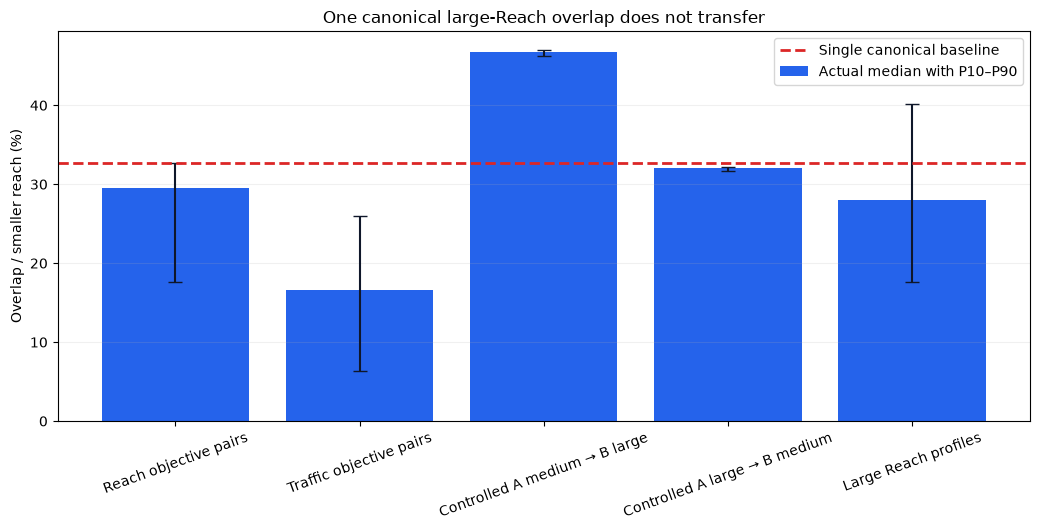

Evaluation MAE points,Evaluation P90 error points
7.99,15.45


In [8]:
scenario_groups = {
    "Reach objective pairs": [row for row in evaluation if row.scenario == "objective_reach"],
    "Traffic objective pairs": [row for row in evaluation if row.scenario == "objective_traffic"],
    "Controlled A medium → B large": [row for row in evaluation if row.scenario == "direction_medium_large"],
    "Controlled A large → B medium": [row for row in evaluation if row.scenario == "direction_large_medium"],
    "Large Reach profiles": [row for row in evaluation if row.scenario == "large_reach_profiles"],
}
labels = list(scenario_groups)
group_values = {
    label: 100 * np.asarray([row.overlap_rate for row in scenario_groups[label]])
    for label in labels
}
medians = np.asarray([np.median(group_values[label]) for label in labels])
p10 = np.asarray([np.quantile(group_values[label], 0.10) for label in labels])
p90 = np.asarray([np.quantile(group_values[label], 0.90) for label in labels])
baseline = diagnostic["baseline_overlap_percent"]
fig, ax = plt.subplots(figsize=(10.5, 5.4))
x = np.arange(len(labels))
ax.bar(
    x,
    medians,
    yerr=[medians - p10, p90 - medians],
    color="#2563eb",
    ecolor="#0f172a",
    capsize=5,
    label="Actual median with P10–P90",
)
ax.axhline(baseline, color="#dc2626", linestyle="--", linewidth=2, label="Single canonical baseline")
ax.set(ylabel="Overlap / smaller reach (%)", title="One canonical large-Reach overlap does not transfer", xticks=x, xticklabels=labels)
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.18)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT / "global_baseline.png", dpi=180)
plt.show()
show_table([diagnostic["global_model"]], [
    ("evaluation_mae_points", "Evaluation MAE points"),
    ("evaluation_p90_error_points", "Evaluation P90 error points"),
])

## Scope and remaining shortcut

This version improves interpretability, not realism in every dimension.

- It starts from known people and does not model accounts or VID assignment.
- It fixes publisher reach and studies audience composition at that size.
- Its optional reference exercise assumes fingerprint availability is independent of campaign delivery and uses known coverage and agreement rates.
- Its activity and response patterns are synthetic and not estimates of any publisher.
- Its campaign profiles are stylized summaries of real settings.
- Campaign-profile strength is restricted to 0–1.25 so every interpolated flight remains positive.

Those choices make the causal comparisons readable. The companion sensitivity notebook tests whether the results require narrow parameter values. Its main standard is not that every random configuration reproduces all three discrepancies; null mechanisms should produce null effects. The standard is that each discrepancy grows smoothly when its stated mechanism is strengthened and disappears when that mechanism is removed.

## Optional calibration exercise: can a campaign reference repair the fixed baseline?

The tests above explain why one canonical overlap does not transfer. This final exercise asks whether a **partial campaign-specific reference** can correct it.

The synthetic reference observes only a subset of the people reached on both publishers:

- 30% of people have a usable reference on Publisher A;
- 80% have one on Publisher B; and
- when the same person has references on both, they agree 60% of the time.

The expected observation rate for a truly shared person is therefore:

$$0.30\times0.80\times0.60=0.144$$

The correction is deliberately simple:

$$\widehat{overlap}=\frac{\text{observed cross-publisher reference matches}}
{0.144\times\text{smaller publisher reach}}$$

This does not change either publisher's reach. It changes only the estimated shared audience and therefore total and incremental unique reach.

### In plain language

The fixed model applies the same overlap learned from canonical Reach campaigns to every campaign. The reference estimate instead asks each campaign for a noisy, partial indication of who appeared on both publishers, then corrects for how often that signal is observable.

If the partial matched group behaves like the rest of the campaign, it can reveal whether this campaign belongs above or below the canonical baseline.

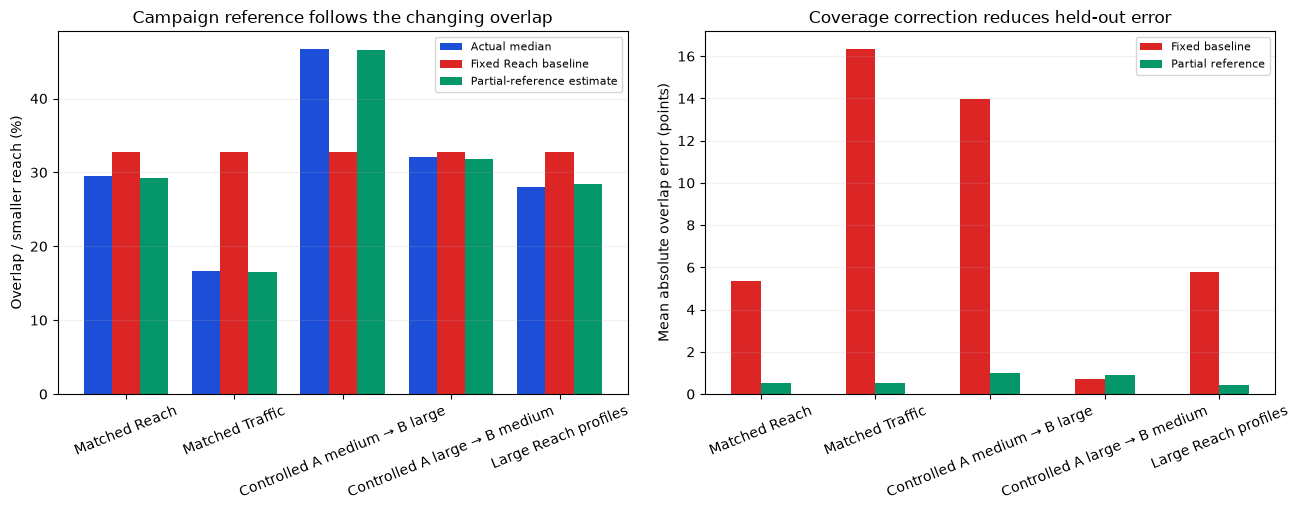

Evaluation group,Campaigns,Fixed overlap MAE points,Reference overlap MAE points,Fixed incremental unique MAPE %,Reference incremental unique MAPE %,Fixed incremental unique P90 error %,Reference incremental unique P90 error %
Matched Reach,32,5.37,0.53,6.77,0.74,18.40,1.25
Matched Traffic,32,16.36,0.52,18.99,0.65,28.20,1.20
Controlled A medium → B large,24,13.98,1.01,26.23,1.90,26.97,3.86
Controlled A large → B medium,24,0.73,0.89,1.07,1.31,1.55,2.51
Large Reach profiles,70,5.80,0.44,7.93,0.62,18.37,1.36


In [9]:
calibration = diagnostic["reference_calibration"]
calibration_rows = calibration["groups"]
labels = [row["group"] for row in calibration_rows]
actual = np.asarray([row["actual_median_overlap_percent"] for row in calibration_rows])
fixed = np.asarray([row["fixed_overlap_percent"] for row in calibration_rows])
reference = np.asarray([row["reference_median_overlap_percent"] for row in calibration_rows])

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.2))
x = np.arange(len(labels))
width = 0.26
axes[0].bar(x - width, actual, width, label="Actual median", color="#1d4ed8")
axes[0].bar(x, fixed, width, label="Fixed Reach baseline", color="#dc2626")
axes[0].bar(x + width, reference, width, label="Partial-reference estimate", color="#059669")
axes[0].set(ylabel="Overlap / smaller reach (%)", title="Campaign reference follows the changing overlap", xticks=x, xticklabels=labels)
axes[0].tick_params(axis="x", rotation=22)
axes[0].grid(axis="y", alpha=0.18)
axes[0].legend(fontsize=8)

fixed_mae = np.asarray([row["fixed_mae_points"] for row in calibration_rows])
reference_mae = np.asarray([row["reference_mae_points"] for row in calibration_rows])
axes[1].bar(x - width / 2, fixed_mae, width, label="Fixed baseline", color="#dc2626")
axes[1].bar(x + width / 2, reference_mae, width, label="Partial reference", color="#059669")
axes[1].set(ylabel="Mean absolute overlap error (points)", title="Coverage correction reduces held-out error", xticks=x, xticklabels=labels)
axes[1].tick_params(axis="x", rotation=22)
axes[1].grid(axis="y", alpha=0.18)
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT / "reference_calibration.png", dpi=180)
plt.show()

show_table(calibration_rows, [
    ("group", "Evaluation group"),
    ("campaigns", "Campaigns"),
    ("fixed_mae_points", "Fixed overlap MAE points"),
    ("reference_mae_points", "Reference overlap MAE points"),
    ("fixed_incremental_unique_mape_percent", "Fixed incremental unique MAPE %"),
    ("reference_incremental_unique_mape_percent", "Reference incremental unique MAPE %"),
    ("fixed_incremental_unique_p90_error_percent", "Fixed incremental unique P90 error %"),
    ("reference_incremental_unique_p90_error_percent", "Reference incremental unique P90 error %"),
])

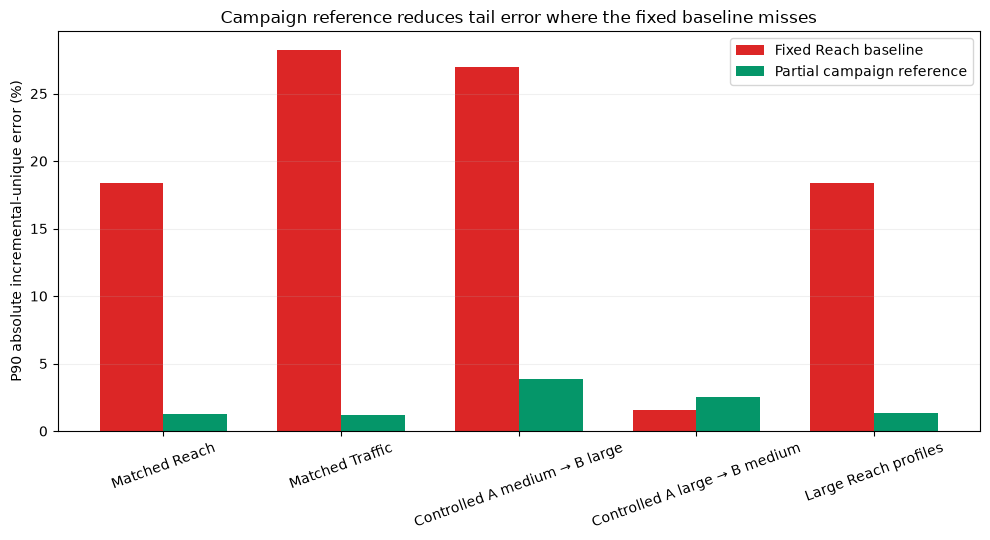

In [10]:
fixed_p90 = np.asarray([
    row["fixed_incremental_unique_p90_error_percent"]
    for row in calibration_rows
])
reference_p90 = np.asarray([
    row["reference_incremental_unique_p90_error_percent"]
    for row in calibration_rows
])
fig, ax = plt.subplots(figsize=(10.0, 5.5))
x = np.arange(len(labels))
width = 0.36
ax.bar(x - width / 2, fixed_p90, width, label="Fixed Reach baseline", color="#dc2626")
ax.bar(x + width / 2, reference_p90, width, label="Partial campaign reference", color="#059669")
ax.set(
    ylabel="P90 absolute incremental-unique error (%)",
    title="Campaign reference reduces tail error where the fixed baseline misses",
    xticks=x,
    xticklabels=labels,
)
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.18)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT / "reference_incremental_unique_error.png", dpi=180)
plt.show()

> **Calibration conclusion.** In this controlled population, the partial campaign reference follows all three changing overlap patterns and substantially improves the groups that the fixed baseline misses. A group already close to the baseline can instead gain only noise. The exercise shows how campaign-specific information could repair a one-number baseline and improve the smaller publisher's incremental unique-reach estimate where miscalibration is material.

> **Important limitation.** This is a deliberately favorable upper-bound exercise, not independent validation. The reference is created by randomly thinning the simulator's true shared-person set, and the correction knows the exact coverage and agreement rates. Real use would need to establish that reference availability is representative, that the rates are estimable, and that the result holds against an external people-based benchmark. The reference does not prove the synthetic mechanisms are real.